In [14]:
import os
import pandas as pd
from dotenv import load_dotenv
from gsheet_loader import load_sheet

load_dotenv()

# Load a Google Sheet URL from .env
url = os.getenv("GOOGLE_SHEET_URL")
if not url:
    raise ValueError("GOOGLE_SHEET_URL is not set in .env")

data = load_sheet(url)

In [15]:
df = pd.read_csv(data)

In [16]:
df.drop('submittedAt', axis=1, inplace=True)

In [17]:
df['B5_time_with_parents_hours'] = df['B5_time_with_parents_hours'].str.replace('â', '-', regex=False)
df['D1_daily_screen'] = df['D1_daily_screen'].str.replace('â', '-', regex=False)
df['D2_weekend_screen'] = df['D2_weekend_screen'].str.replace('â', '-', regex=False)
df['D5_parents_screen_time'] = df['D5_parents_screen_time'].str.replace('â', '-', regex=False)
df['E1_sleep_duration'] = df['E1_sleep_duration'].str.replace('â', '-', regex=False)

## **Outlier Detection**

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ── Numeric columns (already numbers) ─────────────────────────────────────
numeric_cols = [
    'A1_age_years', 'B3_income_tk',
    'C1_height_feet', 'C1_height_inches', 'C2_weight_kg', 'BMI',
    'PHQ9_1', 'PHQ9_2', 'PHQ9_3', 'PHQ9_4', 'PHQ9_5',
    'PHQ9_6', 'PHQ9_7', 'PHQ9_8', 'PHQ9_9', 'total_PHQ'
]

# ── Range-string columns → midpoint numeric ────────────────────────────────
range_cols = [
    'B5_time_with_parents_hours', 'D1_daily_screen',
    'D2_weekend_screen', 'D5_parents_screen_time', 'E1_sleep_duration'
]

range_map = {
    # time with parents / screen time
    'Less than 1 hour': 0.5, '<1 hour': 0.5, 'Less than 1': 0.5,
    '1-2 hours': 1.5, '2-4 hours': 3.0, '4-6 hours': 5.0,
    'More than 6 hours': 7.0, '6+ hours': 7.0,
    # daily screen / weekend screen
    'Less than 1': 0.5, '1-2': 1.5, '2-3': 2.5, '3-5': 4.0,
    '5-7': 6.0, '7-9': 8.0, 'More than 9': 10.0,
    '1-2 hours': 1.5, '3-5 hours': 4.0, '5-7 hours': 6.0,
    '7-9 hours': 8.0, 'More than 9 hours': 10.0,
    # sleep duration
    'Less than 5 hours': 4.5, '5-6 hours': 5.5, '6-7 hours': 6.5,
    '7-8 hours': 7.5, 'More than 8 hours': 9.0,
}

def parse_range(val):
    if pd.isna(val):
        return np.nan
    v = str(val).strip()
    if v in range_map:
        return range_map[v]
    if '-' in v:
        parts = v.replace(' hours','').replace(' hour','').split('-')
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except:
            pass
    for kw, rep in [('Less than ', ''), ('More than ', ''), ('<', ''), ('>', ''), (' hours', ''), (' hour', '')]:
        v = v.replace(kw, rep)
    try:
        return float(v.strip())
    except:
        return np.nan

# ── Ordinal Likert columns → ordered integer encoding ─────────────────────
ordinal_mappings = {
    # Frequency
    'G1_mood_swings':          {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Always': 4},
    'G2_anxious_without_device':{'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Always': 4},
    'G3_communication':        {'Very good': 4, 'Good': 3, 'Moderate': 2, 'Bad': 1, 'Very bad': 0},
    'G4_isolation':            {'No time': 0, 'Very little time': 1, 'Moderate time': 2,
                                'Most of the time': 3, 'All the time': 4},
    'G5_negative_mental':      {'Yes': 2, 'Not sure': 1, 'No': 0},
    'G6_panic_attack':         {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Always': 4},
    'G7_personality':          {'Yes': 2, 'Not sure': 1, 'No': 0},
    'H1_mobile_while_eating':  {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Always': 4},
    'H2_appetite_change':      {'No change': 0, 'Slight change': 1, 'Loss of appetite': 2,
                                'Increased appetite': 2, 'Significant change': 3},
    'F1_academic_satisfaction':{'Very satisfied': 4, 'Satisfied': 3, 'Neutral': 2,
                                'Unsatisfied': 1, 'Very unsatisfied': 0},
    'F2_screen_impact':        {'Very positive': 4, 'Positive': 3, 'Neutral': 2,
                                'Negative': 1, 'Very negative': 0},
    'F3_learning_interest':    {'Very high': 4, 'High': 3, 'Moderate': 2, 'Low': 1, 'Very low': 0},
    'F4_interest_reduced':     {'Not reduced': 0, 'Slightly reduced': 1, 'Decreased moderately': 2,
                                'Significantly reduced': 3, 'Completely lost interest': 4},
    'D6_ai_daily':             {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Always': 4},
    'D7_ai_impact':            {'Very positive': 4, 'Positive': 3, 'Neutral': 2,
                                'Negative': 1, 'Very negative': 0},
    'D8_creativity_decline':   {'Strongly agree': 4, 'Agree': 3, 'Neutral': 2,
                                'Disagree': 1, 'Strongly disagree': 0},
    'E2_after_sleep_feel':     {'Very refreshed': 4, 'Refreshed': 3, 'Neutral': 2,
                                'Tired': 1, 'Very tired': 0},
    'B6_relationship_with_family': {'Very good': 4, 'Good': 3, 'Moderate': 2, 'Bad': 1, 'Very bad': 0},
}

print(f"Numeric columns    : {len(numeric_cols)}")
print(f"Range-string cols  : {len(range_cols)}")
print(f"Ordinal Likert cols: {len(ordinal_mappings)}")
print(f"Total cols analysed: {len(numeric_cols) + len(range_cols) + len(ordinal_mappings)}")

Numeric columns    : 16
Range-string cols  : 5
Ordinal Likert cols: 18
Total cols analysed: 39


In [19]:
# ── Build unified numeric working frame ────────────────────────────────────
df_work = pd.DataFrame(index=df.index)

for col in numeric_cols:
    if col in df.columns:
        df_work[col] = pd.to_numeric(df[col], errors='coerce')

for col in range_cols:
    if col in df.columns:
        df_work[col] = df[col].apply(parse_range)

for col, mapping in ordinal_mappings.items():
    if col in df.columns:
        df_work[col] = df[col].astype(str).str.strip().map(mapping)

all_cols = list(df_work.columns)
print(f"Total columns ready for outlier detection: {len(all_cols)}")
print(all_cols)
df_work.head(3)

Total columns ready for outlier detection: 37
['A1_age_years', 'B3_income_tk', 'C1_height_feet', 'C1_height_inches', 'C2_weight_kg', 'PHQ9_1', 'PHQ9_2', 'PHQ9_3', 'PHQ9_4', 'PHQ9_5', 'PHQ9_6', 'PHQ9_7', 'PHQ9_8', 'PHQ9_9', 'B5_time_with_parents_hours', 'D1_daily_screen', 'D2_weekend_screen', 'D5_parents_screen_time', 'E1_sleep_duration', 'G1_mood_swings', 'G2_anxious_without_device', 'G3_communication', 'G4_isolation', 'G5_negative_mental', 'G6_panic_attack', 'G7_personality', 'H1_mobile_while_eating', 'H2_appetite_change', 'F1_academic_satisfaction', 'F2_screen_impact', 'F3_learning_interest', 'F4_interest_reduced', 'D6_ai_daily', 'D7_ai_impact', 'D8_creativity_decline', 'E2_after_sleep_feel', 'B6_relationship_with_family']


,A1_age_years,B3_income_tk,C1_height_feet,C1_height_inches,C2_weight_kg,PHQ9_1,PHQ9_2,PHQ9_3,PHQ9_4,PHQ9_5,...,H2_appetite_change,F1_academic_satisfaction,F2_screen_impact,F3_learning_interest,F4_interest_reduced,D6_ai_daily,D7_ai_impact,D8_creativity_decline,E2_after_sleep_feel,B6_relationship_with_family
0,14,540000,5,4,52,NaN,NaN,NaN,NaN,NaN,...,2.0,NaN,NaN,2.0,2.0,NaN,NaN,NaN,NaN,3
1,13,150000,5,1,40,NaN,NaN,NaN,NaN,NaN,...,2.0,NaN,NaN,NaN,2.0,3.0,NaN,NaN,NaN,4
2,12,100000,4,10,32,NaN,NaN,NaN,NaN,NaN,...,2.0,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,3


In [20]:
# ── IQR outlier detection across ALL columns ──────────────────────────────
def iqr_outliers(series):
    s = series.dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mask = (series < lo) | (series > hi)
    return mask.fillna(False), lo, hi, Q1, Q3, IQR

summary_rows = []
outlier_flag_df = pd.DataFrame(index=df_work.index)

for col in all_cols:
    series = df_work[col]
    if series.dropna().nunique() < 2:
        outlier_flag_df[col] = False
        continue
    mask, lo, hi, Q1, Q3, IQR = iqr_outliers(series)
    outlier_flag_df[col] = mask
    n_out = mask.sum()
    col_type = ('Numeric' if col in numeric_cols
                else 'Range→Numeric' if col in range_cols
                else 'Ordinal')
    summary_rows.append({
        'Column': col,
        'Type': col_type,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Fence': round(lo, 2),
        'Upper Fence': round(hi, 2),
        'N Outliers': n_out,
        'Outlier %': round(100 * n_out / series.notna().sum(), 1),
        'Outlier Values': sorted(series[mask].unique().tolist()) if n_out else []
    })

summary_df = pd.DataFrame(summary_rows)
outlier_flag_df['ANY_outlier'] = outlier_flag_df.any(axis=1)

print(f"{'='*65}")
print(f"  IQR Outlier Detection — {len(all_cols)} columns, {len(df_work)} rows")
print(f"{'='*65}")
print(summary_df[['Column','Type','Lower Fence','Upper Fence','N Outliers','Outlier %','Outlier Values']].to_string(index=False))
print(f"\nRows flagged as outlier in at least 1 column: "
      f"{outlier_flag_df['ANY_outlier'].sum()} / {len(df_work)} "
      f"({100*outlier_flag_df['ANY_outlier'].mean():.1f}%)")

  IQR Outlier Detection — 37 columns, 452 rows
                     Column          Type  Lower Fence  Upper Fence  N Outliers  Outlier %                                                                                                                                                                                      Outlier Values
               A1_age_years       Numeric         9.50        21.50           0        0.0                                                                                                                                                                                                  []
               B3_income_tk       Numeric   -818750.00   1631250.00          72       15.9 [1800000, 1960000, 2000000, 2500000, 2530000, 3000000, 3600000, 4000000, 4400000, 4500000, 4800000, 5000000, 6000000, 8000000, 9000000, 10000000, 15000000, 20000000, 30000000, 40000000, 50000000]
             C1_height_feet       Numeric         5.00         5.00          81       17.9  

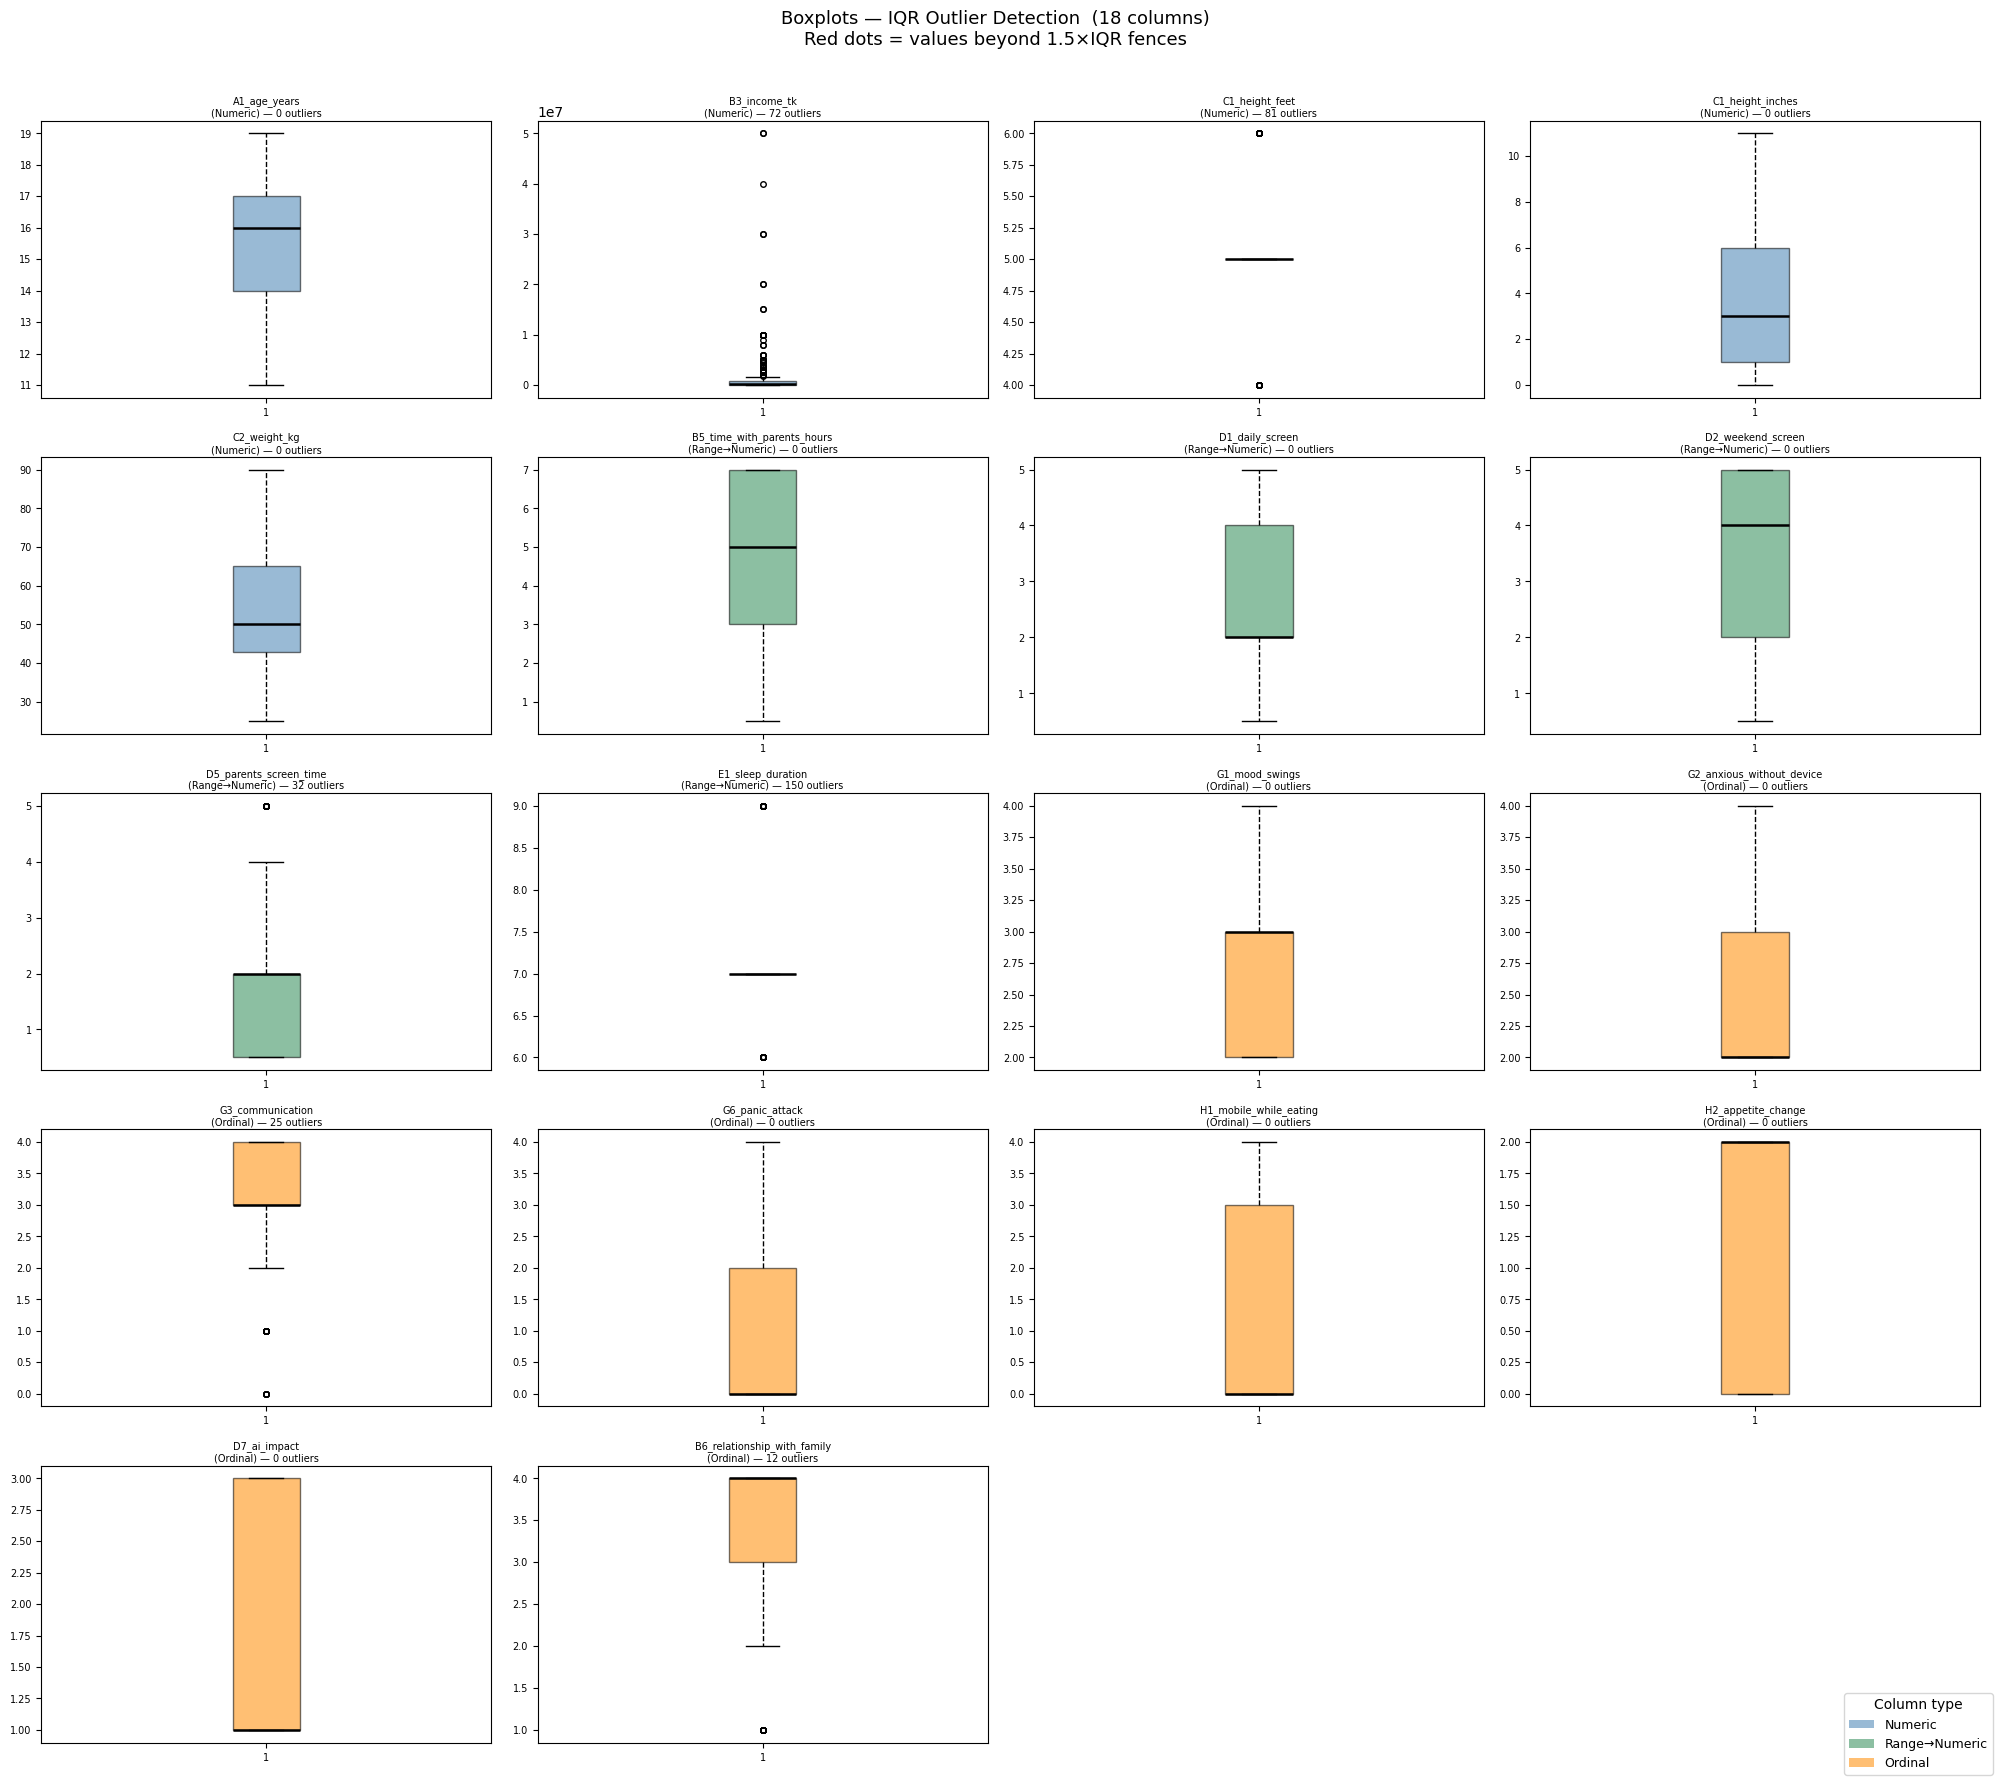

In [21]:
# ── Boxplots for all columns ───────────────────────────────────────────────
cols_to_plot = [r['Column'] for r in summary_rows]
n = len(cols_to_plot)
ncols = 4
nrows = (n + ncols - 1) // ncols

type_colors = {'Numeric': 'steelblue', 'Range→Numeric': 'seagreen', 'Ordinal': 'darkorange'}

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = axes.flatten()

for i, row in enumerate(summary_rows):
    col = row['Column']
    color = type_colors[row['Type']]
    ax = axes[i]
    series = df_work[col].dropna()
    ax.boxplot(series, vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.55),
               flierprops=dict(marker='o', color='red', markersize=4),
               medianprops=dict(color='black', linewidth=1.8),
               whiskerprops=dict(linestyle='--'))
    n_out = row['N Outliers']
    ax.set_title(f"{col}\n({row['Type']}) — {n_out} outliers",
                 fontsize=7, pad=3)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, alpha=0.55, label=t) for t, c in type_colors.items()]
fig.legend(handles=legend_handles, loc='lower right', fontsize=9, title='Column type')

plt.suptitle(f'Boxplots — IQR Outlier Detection  ({n} columns)\nRed dots = values beyond 1.5×IQR fences',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [22]:
# ── Per-row outlier flag summary ───────────────────────────────────────────
total = len(df_work)
flagged_rows = outlier_flag_df['ANY_outlier'].sum()
print(f"Total rows            : {total}")
print(f"Outlier rows (≥1 col) : {flagged_rows}  ({100*flagged_rows/total:.1f}%)")
print(f"Clean rows            : {total - flagged_rows}  ({100*(total-flagged_rows)/total:.1f}%)")

print("\n─── Columns WITH outliers ───────────────────────────────────────────")
has_outliers = summary_df[summary_df['N Outliers'] > 0][
    ['Column', 'Type', 'N Outliers', 'Outlier %', 'Outlier Values']
].reset_index(drop=True)
print(has_outliers.to_string(index=False))

print("\n─── Columns with NO outliers ────────────────────────────────────────")
no_outliers = summary_df[summary_df['N Outliers'] == 0]['Column'].tolist()
print(no_outliers)

Total rows            : 452
Outlier rows (≥1 col) : 261  (57.7%)
Clean rows            : 191  (42.3%)

─── Columns WITH outliers ───────────────────────────────────────────
                     Column          Type  N Outliers  Outlier %                                                                                                                                                                                      Outlier Values
               B3_income_tk       Numeric          72       15.9 [1800000, 1960000, 2000000, 2500000, 2530000, 3000000, 3600000, 4000000, 4400000, 4500000, 4800000, 5000000, 6000000, 8000000, 9000000, 10000000, 15000000, 20000000, 30000000, 40000000, 50000000]
             C1_height_feet       Numeric          81       17.9                                                                                                                                                                                              [4, 6]
     D5_parents_screen_time Range→Numeric   